# Load example arrays from the repo and run Fill-Spill-Merge.

In [ ]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path("../")
DATA_DIR = REPO_ROOT / "examples" / "data"

# Make the repo package importable when running this script directly.
sys.path.insert(0, str(REPO_ROOT))
from fillspillmerge import fill_spill_merge

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


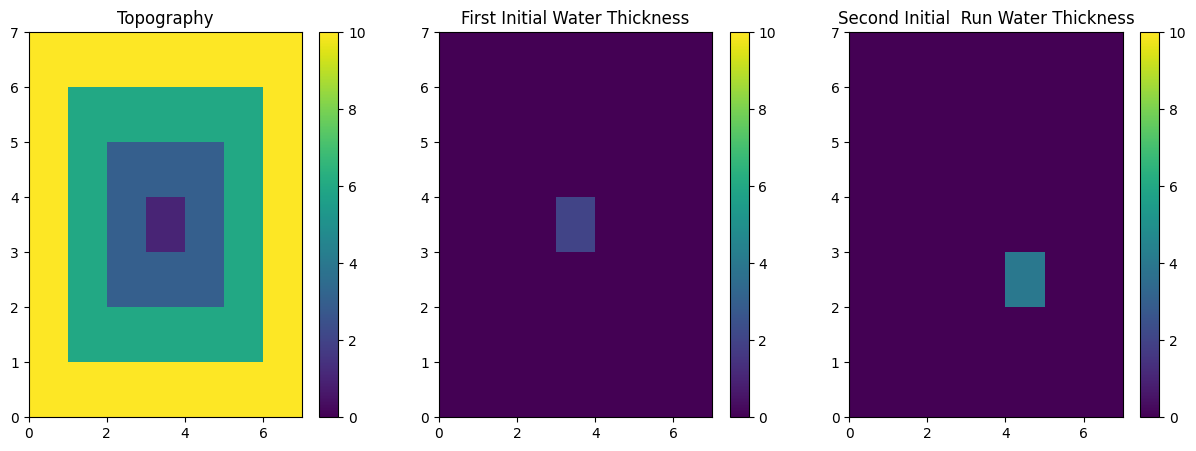

In [ ]:
topography = np.loadtxt(DATA_DIR / "topography.csv", delimiter=",", dtype=np.float64)
in1 = np.zeros_like(topography); in1[3,3] = 2.0 #np.loadtxt(DATA_DIR / "wtd_initial.csv", delimiter=",", dtype=np.float64)
in2 = np.zeros_like(topography); in2[2,4] = 4.0 #np.loadtxt(DATA_DIR / "wtd_initial.csv", delimiter=",", dtype=np.float64)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title("Topography")
im0 = axes[0].pcolormesh(topography, shading="auto", clim=(0, 10))
fig.colorbar(im0, ax=axes[0])   
axes[1].set_title("First Initial Water Thickness")
im1 = axes[1].pcolormesh(in1, shading="auto", clim=(0, 10))
fig.colorbar(im1, ax=axes[1])
axes[2].set_title("Second Initial  Run Water Thickness")
im2 = axes[2].pcolormesh(in2, shading="auto", clim=(0, 10))
fig.colorbar(im2, ax=axes[2])

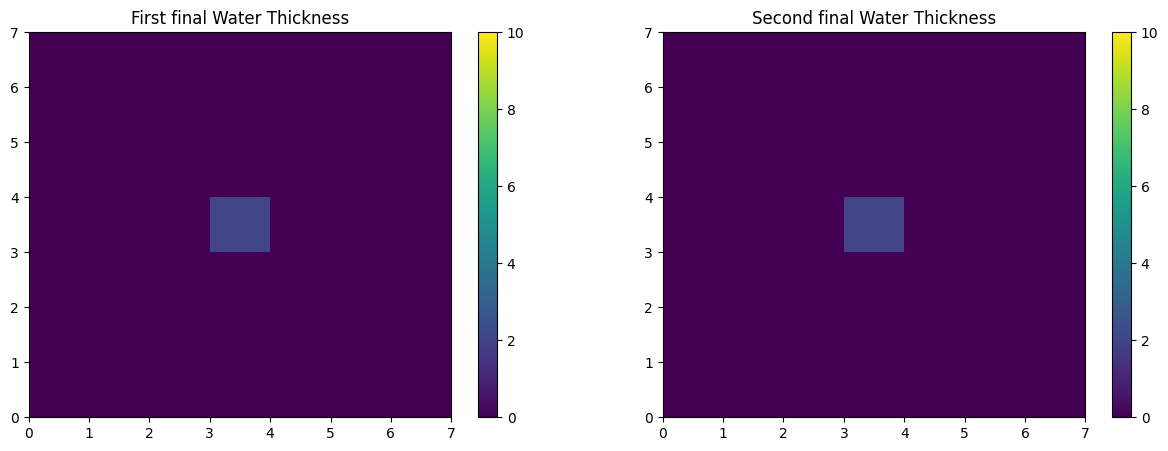

In [3]:
out1 = fill_spill_merge(
    wtd=in1,
    topography=topography,
    ocean_level=10.0,)
out2 = fill_spill_merge(
    wtd=in1,
    topography=topography,
    ocean_level=10.0,)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title("First final Water Thickness")
im0 = axes[0].pcolormesh(out1, shading="auto", clim=(0, 10))
fig.colorbar(im0, ax=axes[0])   
axes[1].set_title("Second final Water Thickness")
im1 = axes[1].pcolormesh(out2, shading="auto", clim=(0, 10))
fig.colorbar(im1, ax=axes[1])


In [26]:
dem.rio.to_raster(DATA_DIR / "topography.tif")

In [28]:
import rioxarray

topography_full = rioxarray.open_rasterio(DATA_DIR / "topography.tif", chunks={}).squeeze()
# topography_full.rio.to_raster(DATA_DIR / "topography.tif") # save the DEM as a GeoTIFF for use in the example

# fill NaN values
topography_full = topography_full.fillna(0).values

# optionally coarsen the DEM to speed up the example
coarsen_factor = 1
topography = topography_full[::coarsen_factor, ::coarsen_factor]

#add ocean cells around the edge of the DEM
topography[0:1,:] = 0.0 
topography[-1:,:] = 0.0
topography[:,0:1] = 0.0
topography[:,-1:] = 0.0


In [30]:
out, hier = fill_spill_merge(
    wtd=np.zeros_like(topography, dtype=np.float64),
    topography=topography,
    ocean_level=0.0,
    nodata=None,
    return_hierarchy=True,
)

In [15]:
import xarray_sweep as xs

wtd_temp = dem.copy()
def run_melt(m):
    melt = topography * 0 + m
    out1 = fill_spill_merge(wtd=melt, hierarchy=hier, nodata=None)
    wtd_temp.values = out1
    return wtd_temp

da_melt  = xs.xarray_sweep(run_melt, m = [0.01, 1])
da_melt

100%|██████████| 2/2 [00:04<00:00,  2.40s/it]


<xarray.DataArray (y: 4095, x: 1024, m: 2)> Size: 67MB
array([[[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
...
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]]], shape=(4095, 1024, 2))
Coordinates:
  * m        (m) float64 16B 0.01 1.0
Dimensions without coordinates: y, x
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

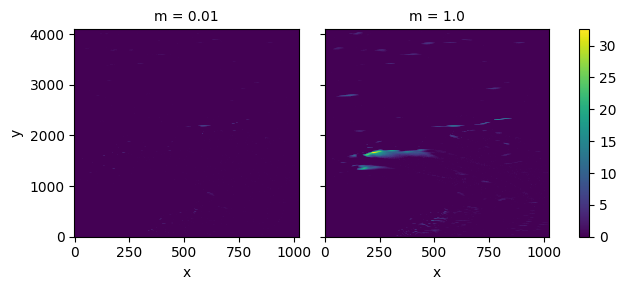

In [16]:
da_melt.plot(col="m", col_wrap=2)